# Statistical Rigor Analysis: KAN vs Baselines

## Contents
1. K-Fold Cross-Validation with confidence intervals
2. Statistical Significance Testing (p-values)
3. Feature Importance
4. Computational Complexity
5. Ablation Studies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from scipy import stats
import xgboost as xgb

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(42)
torch.manual_seed(42)
device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Load data
df = pd.read_excel('../data/High_Accuracy_Sport_Injury_Dataset.xlsx')
X = df.drop('Injury_Risk', axis=1).values
y = df['Injury_Risk'].values
feature_names = df.drop('Injury_Risk', axis=1).columns.tolist()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features")

Device: mps
Dataset: 600 samples, 15 features


In [2]:
# Model definitions
class MLP(nn.Module):
    def __init__(self, n):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 1), nn.Sigmoid())
    def forward(self, x): return self.net(x)

class ChebyKANLayer(nn.Module):
    def __init__(self, in_f, out_f, degree=4):
        super().__init__()
        self.degree = degree
        self.coeffs = nn.Parameter(torch.randn(in_f, out_f, degree + 1) * 0.1)
        self.bias = nn.Parameter(torch.zeros(out_f))
    def forward(self, x):
        x_n = torch.tanh(x)
        T = [torch.ones_like(x_n), x_n]
        for _ in range(2, self.degree + 1): T.append(2 * x_n * T[-1] - T[-2])
        return torch.einsum('bid,iod->bo', torch.stack(T, dim=-1), self.coeffs) + self.bias

class ChebyKAN(nn.Module):
    def __init__(self, dims, degree=4):
        super().__init__()
        self.layers = nn.ModuleList([ChebyKANLayer(dims[i], dims[i+1], degree) for i in range(len(dims)-1)])
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        for l in self.layers: x = l(x)
        return self.sigmoid(x)

## 1. K-Fold Cross-Validation

In [3]:
def train_eval_fold(model, X_train, y_train, X_test, y_test, epochs=100):
    X_t, y_t = torch.FloatTensor(X_train), torch.FloatTensor(y_train).unsqueeze(1)
    X_test_t = torch.FloatTensor(X_test)
    model = model.to(device)
    opt = optim.Adam(model.parameters(), lr=0.003)
    crit = nn.BCELoss()
    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=32, shuffle=True)
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); loss = crit(model(xb), yb); loss.backward(); opt.step()
    model.eval()
    with torch.no_grad(): y_prob = model(X_test_t.to(device)).cpu().numpy().flatten()
    return accuracy_score(y_test, (y_prob > 0.5).astype(int))

print("=" * 70)
print("5-FOLD CROSS-VALIDATION")
print("=" * 70)

cv_results = {}
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# XGBoost
print("\nXGBoost:")
xgb_scores = cross_val_score(xgb.XGBClassifier(n_estimators=100, max_depth=6, random_state=42, eval_metric='logloss'), X_scaled, y, cv=5)
cv_results['XGBoost'] = xgb_scores
print(f"  Scores: {xgb_scores.round(4)}, Mean: {xgb_scores.mean():.4f}")

# MLP
print("\nMLP:")
mlp_scores = []
for fold, (tr, te) in enumerate(kf.split(X_scaled, y)):
    acc = train_eval_fold(MLP(X.shape[1]), X_scaled[tr], y[tr], X_scaled[te], y[te])
    mlp_scores.append(acc)
    print(f"  Fold {fold+1}: {acc:.4f}")
cv_results['MLP'] = np.array(mlp_scores)

# ChebyKAN
print("\nChebyKAN:")
kan_scores = []
for fold, (tr, te) in enumerate(kf.split(X_scaled, y)):
    acc = train_eval_fold(ChebyKAN([X.shape[1], 64, 32, 1], degree=4), X_scaled[tr], y[tr], X_scaled[te], y[te])
    kan_scores.append(acc)
    print(f"  Fold {fold+1}: {acc:.4f}")
cv_results['ChebyKAN'] = np.array(kan_scores)

5-FOLD CROSS-VALIDATION

XGBoost:


  Scores: [0.9833 0.975  0.95   0.9417 0.9917], Mean: 0.9683

MLP:


  Fold 1: 0.8500


  Fold 2: 0.8500


  Fold 3: 0.8417


...

  Fold 1: 0.8417


  Fold 2: 0.8417


  Fold 3: 0.8750


  Fold 4: 0.8667


  Fold 5: 0.9333


In [4]:
# Confidence intervals
print("\n" + "=" * 70)
print("RESULTS WITH 95% CONFIDENCE INTERVALS")
print("=" * 70 + "\n")

ci_results = []
for name, scores in cv_results.items():
    mean, std, n = np.mean(scores), np.std(scores), len(scores)
    ci = stats.t.interval(0.95, n-1, loc=mean, scale=std/np.sqrt(n))
    ci_results.append({'Model': name, 'Mean': mean, 'Std': std, 'CI Lower': ci[0], 'CI Upper': ci[1]})
    print(f"{name}: {mean:.4f} ± {std:.4f} (95% CI: [{ci[0]:.4f}, {ci[1]:.4f}])")

ci_df = pd.DataFrame(ci_results)
display(ci_df.round(4))


RESULTS WITH 95% CONFIDENCE INTERVALS

XGBoost: 0.9683 ± 0.0193 (95% CI: [0.9444, 0.9923])
MLP: 0.8683 ± 0.0266 (95% CI: [0.8354, 0.9013])
ChebyKAN: 0.8717 ± 0.0336 (95% CI: [0.8300, 0.9134])


,Model,Mean,Std,CI Lower,CI Upper
0,XGBoost,0.9683,0.0193,0.9444,0.9923
1,MLP,0.8683,0.0266,0.8354,0.9013
2,ChebyKAN,0.8717,0.0336,0.8300,0.9134


## 2. Statistical Significance (Paired t-test)

In [5]:
print("=" * 70)
print("STATISTICAL SIGNIFICANCE TESTS")
print("=" * 70)

comparisons = [
    ('ChebyKAN', 'XGBoost'),
    ('ChebyKAN', 'MLP'),
    ('MLP', 'XGBoost')
]

sig_results = []
for m1, m2 in comparisons:
    t_stat, p_val = stats.ttest_rel(cv_results[m1], cv_results[m2])
    sig = 'Yes' if p_val < 0.05 else 'No'
    sig_results.append({'Comparison': f'{m1} vs {m2}', 't-stat': t_stat, 'p-value': p_val, 'Sig (α=0.05)': sig})
    print(f"\n{m1} vs {m2}: t={t_stat:.4f}, p={p_val:.4f} → {'Significant' if p_val < 0.05 else 'Not significant'}")

pd.DataFrame(sig_results)

STATISTICAL SIGNIFICANCE TESTS

ChebyKAN vs XGBoost: t=-5.6874, p=0.0047 → Significant

ChebyKAN vs MLP: t=0.2182, p=0.8379 → Not significant

MLP vs XGBoost: t=-5.6569, p=0.0048 → Significant


,Comparison,t-stat,p-value,Sig (α=0.05)
0,ChebyKAN vs XGBoost,-5.687368,0.004720,Yes
1,ChebyKAN vs MLP,0.218218,0.837940,No
2,MLP vs XGBoost,-5.656854,0.004813,Yes


## 3. Feature Importance

FEATURE IMPORTANCE


,Feature,XGBoost,ChebyKAN
12,Injury_History,0.3721,0.0589
14,Training_Intensity,0.1581,0.0774
8,Sleep_Hours,0.1438,0.0696
10,Muscle_Asymmetry,0.1168,0.0759
13,Stress_Level,0.0408,0.0682
1,Gender,0.0379,0.0566
7,Warmup_Time,0.0207,0.0619
2,Height_cm,0.0171,0.0670
4,BMI,0.0167,0.0640
6,Training_Duration,0.0158,0.0705


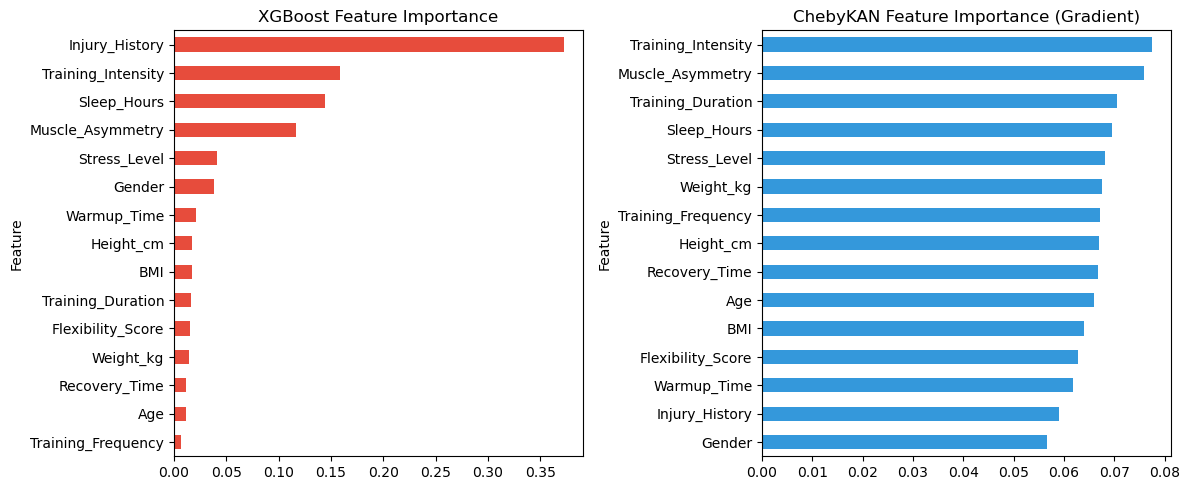

In [6]:
print("=" * 70)
print("FEATURE IMPORTANCE")
print("=" * 70)

# XGBoost importance
xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(X_scaled, y)
xgb_imp = xgb_model.feature_importances_

# ChebyKAN gradient-based importance
kan = ChebyKAN([X.shape[1], 64, 32, 1], degree=4).to(device)
opt = optim.Adam(kan.parameters(), lr=0.003)
X_t = torch.FloatTensor(X_scaled).to(device)
y_t = torch.FloatTensor(y).unsqueeze(1).to(device)
for _ in range(100):
    opt.zero_grad()
    nn.BCELoss()(kan(X_t), y_t).backward()
    opt.step()

X_t.requires_grad = True
kan(X_t).sum().backward()
kan_imp = X_t.grad.abs().mean(dim=0).cpu().numpy()
kan_imp = kan_imp / kan_imp.sum()

imp_df = pd.DataFrame({'Feature': feature_names, 'XGBoost': xgb_imp, 'ChebyKAN': kan_imp}).sort_values('XGBoost', ascending=False)
display(imp_df.round(4))

# Plot
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
imp_df.sort_values('XGBoost').plot.barh(x='Feature', y='XGBoost', ax=ax[0], color='#e74c3c', legend=False)
ax[0].set_title('XGBoost Feature Importance')
imp_df.sort_values('ChebyKAN').plot.barh(x='Feature', y='ChebyKAN', ax=ax[1], color='#3498db', legend=False)
ax[1].set_title('ChebyKAN Feature Importance (Gradient)')
plt.tight_layout()
plt.savefig('../figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Computational Complexity

In [7]:
print("=" * 70)
print("COMPUTATIONAL COMPLEXITY")
print("=" * 70)

def count_params(m): return sum(p.numel() for p in m.parameters())
def measure_time(model_fn, X, y, epochs=50):
    model = model_fn().to(device)
    X_t, y_t = torch.FloatTensor(X[:200]).to(device), torch.FloatTensor(y[:200]).unsqueeze(1).to(device)
    opt = optim.Adam(model.parameters(), lr=0.003)
    start = time.time()
    for _ in range(epochs):
        opt.zero_grad(); nn.BCELoss()(model(X_t), y_t).backward(); opt.step()
    return count_params(model), time.time() - start

results = []
for name, fn in [('MLP', lambda: MLP(X.shape[1])), ('ChebyKAN', lambda: ChebyKAN([X.shape[1], 64, 32, 1]))]:
    params, t = measure_time(fn, X_scaled, y)
    results.append({'Model': name, 'Parameters': params, 'Time (50 epochs)': f"{t:.2f}s"})
    print(f"{name}: {params:,} params, {t:.2f}s")

pd.DataFrame(results)

COMPUTATIONAL COMPLEXITY
MLP: 3,137 params, 0.17s


ChebyKAN: 15,297 params, 0.12s


,Model,Parameters,Time (50 epochs)
0,MLP,3137,0.17s
1,ChebyKAN,15297,0.12s


## 5. Ablation Study: Polynomial Degree

ABLATION STUDY: ChebyKAN Polynomial Degree


Degree 2: Acc=0.8417, Params=9,217, Time=2.29s


Degree 3: Acc=0.8667, Params=12,257, Time=2.31s


Degree 4: Acc=0.8583, Params=15,297, Time=2.54s


Degree 5: Acc=0.7667, Params=18,337, Time=2.52s


Degree 6: Acc=0.7417, Params=21,377, Time=2.68s


Degree 7: Acc=0.8000, Params=24,417, Time=2.90s


,Degree,Accuracy,Params,Time (s)
0,2,0.8417,9217,2.2850
1,3,0.8667,12257,2.3090
2,4,0.8583,15297,2.5380
3,5,0.7667,18337,2.5154
4,6,0.7417,21377,2.6839
5,7,0.8000,24417,2.8972


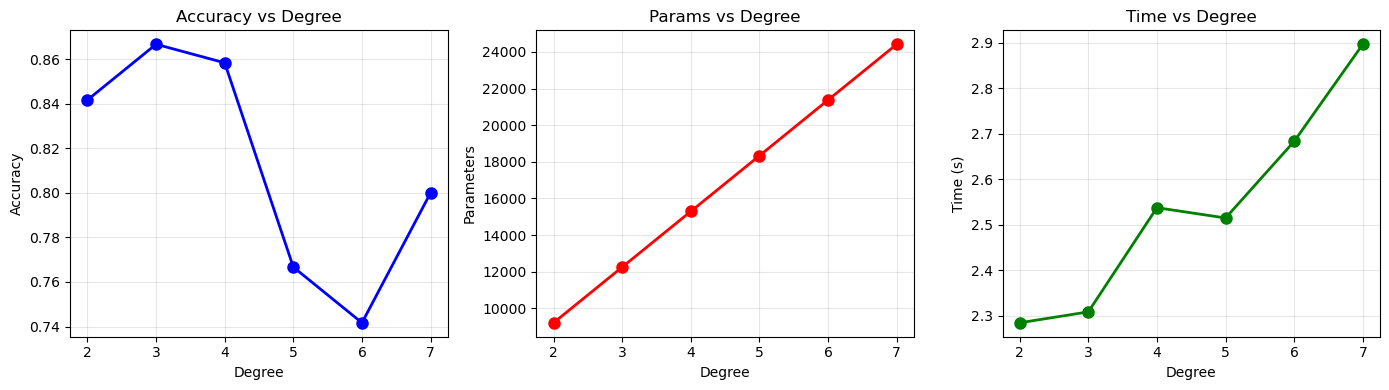

In [8]:
print("=" * 70)
print("ABLATION STUDY: ChebyKAN Polynomial Degree")
print("=" * 70)

X_tr, X_te, y_tr, y_te = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

ablation = []
for deg in [2, 3, 4, 5, 6, 7]:
    model = ChebyKAN([X.shape[1], 64, 32, 1], degree=deg).to(device)
    opt = optim.Adam(model.parameters(), lr=0.003)
    X_t, y_t = torch.FloatTensor(X_tr).to(device), torch.FloatTensor(y_tr).unsqueeze(1).to(device)
    start = time.time()
    for _ in range(100):
        for i in range(0, len(X_t), 32):
            opt.zero_grad()
            nn.BCELoss()(model(X_t[i:i+32]), y_t[i:i+32]).backward()
            opt.step()
    train_time = time.time() - start
    model.eval()
    with torch.no_grad():
        y_prob = model(torch.FloatTensor(X_te).to(device)).cpu().numpy().flatten()
    acc = accuracy_score(y_te, (y_prob > 0.5).astype(int))
    params = count_params(model)
    ablation.append({'Degree': deg, 'Accuracy': acc, 'Params': params, 'Time (s)': train_time})
    print(f"Degree {deg}: Acc={acc:.4f}, Params={params:,}, Time={train_time:.2f}s")

abl_df = pd.DataFrame(ablation)
display(abl_df.round(4))

# Plot
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].plot(abl_df['Degree'], abl_df['Accuracy'], 'bo-', lw=2, ms=8)
ax[0].set_xlabel('Degree'); ax[0].set_ylabel('Accuracy'); ax[0].set_title('Accuracy vs Degree'); ax[0].grid(alpha=0.3)
ax[1].plot(abl_df['Degree'], abl_df['Params'], 'ro-', lw=2, ms=8)
ax[1].set_xlabel('Degree'); ax[1].set_ylabel('Parameters'); ax[1].set_title('Params vs Degree'); ax[1].grid(alpha=0.3)
ax[2].plot(abl_df['Degree'], abl_df['Time (s)'], 'go-', lw=2, ms=8)
ax[2].set_xlabel('Degree'); ax[2].set_ylabel('Time (s)'); ax[2].set_title('Time vs Degree'); ax[2].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

In [9]:
print("\n" + "=" * 70)
print("PUBLICATION-READY SUMMARY")
print("=" * 70)
print("\n📊 Cross-Validation Results:")
display(ci_df.round(4))
print("\n📊 Ablation Study:")
display(abl_df.round(4))


PUBLICATION-READY SUMMARY

📊 Cross-Validation Results:


,Model,Mean,Std,CI Lower,CI Upper
0,XGBoost,0.9683,0.0193,0.9444,0.9923
1,MLP,0.8683,0.0266,0.8354,0.9013
2,ChebyKAN,0.8717,0.0336,0.8300,0.9134



📊 Ablation Study:


,Degree,Accuracy,Params,Time (s)
0,2,0.8417,9217,2.2850
1,3,0.8667,12257,2.3090
2,4,0.8583,15297,2.5380
3,5,0.7667,18337,2.5154
4,6,0.7417,21377,2.6839
5,7,0.8000,24417,2.8972
